In [1]:
import xarray as xr


In [2]:
ds = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc')
ds

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB ...
    lon_u       (eta_rho, xi_u) float64 3MB ...
    lat_u       (eta_rho, xi_u) float64 3MB ...
    lon_v       (eta_v, xi_rho) float64 3MB ...
    lat_v       (eta_v, xi_rho) float64 3MB ...
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B ...
    sc_w        (s_w) float64 264B ...
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB ...
    radsw       (time, eta_rho, xi_rho) float32 1MB ...
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB ...
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB ...
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB ...
    hel         (time, eta_rho, xi_rho) float32 1MB ...
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [3]:
# These are the key variables you need - check they exist
print(ds['Vtransform'].values)  # should be 1 or 2
print(ds['hc'].values)          # critical depth scalar
print(ds['Cs_r'].values)        # stretching at rho levels, shape (s_rho,)
print(ds['h'])                  # bathymetry, shape (eta_rho, xi_rho)

2.0
200.0
[-9.63890089e-01 -8.82376295e-01 -7.92502695e-01 -6.99357210e-01
 -6.07512274e-01 -5.20509229e-01 -4.40709372e-01 -3.69391458e-01
 -3.06970559e-01 -2.53246212e-01 -2.07626836e-01 -1.69308057e-01
 -1.37401569e-01 -1.11020674e-01 -8.93319972e-02 -7.15828200e-02
 -5.71120009e-02 -4.53505655e-02 -3.58163186e-02 -2.81054134e-02
 -2.18827659e-02 -1.68724531e-02 -1.28487365e-02 -9.62802369e-03
 -7.06188349e-03 -5.03111173e-03 -3.44078309e-03 -2.21619600e-03
 -1.29961084e-03 -6.47686340e-04 -2.29531297e-04 -2.53033246e-05]
<xarray.DataArray 'h' (eta_rho: 542, xi_rho: 602)> Size: 3MB
[326284 values with dtype=float64]
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 539.0 540.0 541.0 542.0
    lon_rho  (eta_rho, xi_rho) float64 3MB ...
    lat_rho  (eta_rho, xi_rho) float64 3MB ...
Attributes:
    long_name:      bathymetry at RHO-points
    units:          meter
    field:          bath, 

In [4]:
import numpy as np
import xarray as xr

h    = ds['h'].values          # (eta_rho, xi_rho)
hc   = float(ds['hc'].values)
Cs_r = ds['Cs_r'].values       # (s_rho,)
s_rho = ds['s_rho'].values     # (s_rho,)
vtrans = int(ds['Vtransform'].values)

if vtrans == 1:
    # Song & Haidvogel 1994
    # z = hc*s + (h - hc)*Cs(s)
    z = (hc * s_rho[:, None, None]
         + (h[None, :, :] - hc) * Cs_r[:, None, None])

elif vtrans == 2:
    # Shchepetkin 2010 (default modern CROCO)
    # z = (hc*s + h*Cs) / (hc + h)  * h
    z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
         / (hc + h[None, :, :])
         * h[None, :, :])

# z shape: (s_rho=32, eta_rho=542, xi_rho=602)
# Values are negative (surface ~ 0, bottom ~ -h)
print(f"Depth range: {z.min():.1f} m  to  {z.max():.1f} m")

Depth range: -4823.1 m  to  -0.6 m


In [5]:
NO3 = ds['NO3'].isel(time=0).values   # (s_rho, eta_rho, xi_rho)
target_depth = -10.0                   # 10 m below surface

# Find sigma level index closest to -10 m at every (j, i) point
idx_10m = np.argmin(np.abs(z - target_depth), axis=0)  # (eta_rho, xi_rho)

# Vectorized extraction — no loop needed
ny, nx = idx_10m.shape
jj, ii = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')
NO3_10m = NO3[idx_10m, jj, ii]   # (eta_rho, xi_rho)

# Mask points shallower than 10 m (depth never reaches -10)
shallow_mask = h < 10.0
NO3_10m[shallow_mask] = np.nan

# Wrap in a clean DataArray
NO3_10m_da = xr.DataArray(
    NO3_10m,
    dims=['eta_rho', 'xi_rho'],
    coords={
        'lat_rho': ds['lat_rho'],
        'lon_rho': ds['lon_rho'],
    },
    attrs={'long_name': 'Nitrate at 10 m depth', 'units': 'mmol N m-3'}
)
print(NO3_10m_da)

<xarray.DataArray (eta_rho: 542, xi_rho: 602)> Size: 1MB
array([[0.01003756, 0.01003763, 0.01017734, ..., 0.        , 0.        ,
        0.        ],
       [0.0100375 , 0.01119396, 0.01265151, ..., 0.        , 0.        ,
        0.        ],
       [0.01008631, 0.01193695, 0.01455433, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.2756622 , 0.8598248 , 0.64541566, ..., 0.        , 0.        ,
        0.        ],
       [0.98441064, 0.86318314, 0.7146523 , ..., 0.        , 0.        ,
        0.        ],
       [1.1355188 , 1.2866268 , 0.9714158 , ..., 0.        , 0.        ,
        0.        ]], dtype=float32)
Coordinates:
    lat_rho  (eta_rho, xi_rho) float64 3MB ...
    lon_rho  (eta_rho, xi_rho) float64 3MB ...
Dimensions without coordinates: eta_rho, xi_rho
Attributes:
    long_name:  Nitrate at 10 m depth
    units:      mmol N m-3


In [6]:
# Print the actual depth of the selected level at a test point
j_test, i_test = 200, 300
print(f"Depth at selected level: {z[idx_10m[j_test, i_test], j_test, i_test]:.2f} m")
print(f"NO3 value there: {NO3_10m[j_test, i_test]:.4f} mmol N m-3")

Depth at selected level: -9.84 m
NO3 value there: 0.8069 mmol N m-3


In [8]:
from pathlib import Path
import re
import numpy as np
import xarray as xr

files = sorted(Path("../../NHCS/hincast_1980-2015/").glob("croco_avg_Y*M*.nc"))

def extract_datetime_from_filename(path):
    match = re.search(r"Y(\d{4})M(\d{2})", path.name)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return np.datetime64(f"{year}-{month:02d}")
    else:
        raise ValueError(f"Fecha no encontrada en nombre: {path.name}")

time_values = [extract_datetime_from_filename(f) for f in files]

def load_no3_10m(path, time_val):
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Depth computation ---
    h     = ds['h'].values
    hc    = float(ds['hc'].values)
    Cs_r  = ds['Cs_r'].values
    s_rho = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z = (hc * s_rho[:, None, None]
             + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
             / (hc + h[None, :, :])
             * h[None, :, :])

    # --- Extract NO3 at 10m ---
    NO3 = ds['NO3'].isel(time=0).values        # (s_rho, eta_rho, xi_rho)
    target_depth = -10.0

    idx_10m = np.argmin(np.abs(z - target_depth), axis=0)  # (eta_rho, xi_rho)

    ny, nx = idx_10m.shape
    jj, ii = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')
    NO3_10m = NO3[idx_10m, jj, ii].astype(np.float32)

    # Mask points shallower than 10m
    NO3_10m[h < 10.0] = np.nan

    # Wrap as DataArray
    NO3_10m_da = xr.DataArray(
        NO3_10m,
        dims=['eta_rho', 'xi_rho'],
        coords={
            'lat_rho': ds['lat_rho'],
            'lon_rho': ds['lon_rho'],
        },
        attrs={'long_name': 'Nitrate at 10m depth', 'units': 'mmol N m-3'}
    )

    return xr.Dataset(
        {"NO3_10m": NO3_10m_da},
        coords={"time": [time_val]}
    )

In [9]:
from tqdm.notebook import tqdm

no3_list = [load_no3_10m(f, t) for f, t in tqdm(zip(files, time_values), total=len(files), desc="Loading NO3 10m")]
no3_all = xr.concat(no3_list, dim="time")
# # Build list and concatenate
# no3_list = [load_no3_10m(f, t) for f, t in zip(files, time_values)]
# no3_all = xr.concat(no3_list, dim="time")

Loading NO3 10m:   0%|          | 0/432 [00:00<?, ?it/s]

In [ ]:
files = sorted(Path("../../NHCS/hincast_1980-2015/").glob("croco_avg_Y*M*.nc"))

def extract_datetime_from_filename(path):
    match = re.search(r"Y(\d{4})M(\d{2})", path.name)
    if match:
        year = int(match.group(1))
        month = int(match.group(2))
        return np.datetime64(f"{year}-{month:02d}")
    else:
        raise ValueError(f"Fecha no encontrada en nombre: {path.name}")

time_values = [extract_datetime_from_filename(f) for f in files]

def load_no3_10m(path, time_val):
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Depth computation ---
    h     = ds['h'].values
    hc    = float(ds['hc'].values)
    Cs_r  = ds['Cs_r'].values
    s_rho = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z = (hc * s_rho[:, None, None]
             + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
             / (hc + h[None, :, :])
             * h[None, :, :])

    # --- Extract NO3 at 10m ---
    NO3 = ds['NO3'].isel(time=0).values        # (s_rho, eta_rho, xi_rho)
    target_depth = -10.0

    idx_10m = np.argmin(np.abs(z - target_depth), axis=0)  # (eta_rho, xi_rho)

    ny, nx = idx_10m.shape
    jj, ii = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')
    NO3_10m = NO3[idx_10m, jj, ii].astype(np.float32)

    # Mask points shallower than 10m
    NO3_10m[h < 10.0] = np.nan

    # Wrap as DataArray
    NO3_10m_da = xr.DataArray(
        NO3_10m,
        dims=['eta_rho', 'xi_rho'],
        coords={
            'lat_rho': ds['lat_rho'],
            'lon_rho': ds['lon_rho'],
        },
        attrs={'long_name': 'Nitrate at 10m depth', 'units': 'mmol N m-3'}
    )

    return xr.Dataset(
        {"NO3_10m": NO3_10m_da},
        coords={"time": [time_val]}
    )

In [11]:
def load_nitrogen_10m(path, time_val):
    time_val = np.datetime64(time_val, 'ns')
    ds = xr.open_dataset(path, chunks={"time": 1})

    # --- Depth computation ---
    h      = ds['h'].values
    hc     = float(ds['hc'].values)
    Cs_r   = ds['Cs_r'].values
    s_rho  = ds['s_rho'].values
    vtrans = int(ds['Vtransform'].values)

    if vtrans == 1:
        z = (hc * s_rho[:, None, None]
             + (h[None, :, :] - hc) * Cs_r[:, None, None])
    elif vtrans == 2:
        z = ((hc * s_rho[:, None, None] + h[None, :, :] * Cs_r[:, None, None])
             / (hc + h[None, :, :])
             * h[None, :, :])

    # --- Shared index for 10m ---
    target_depth = -10.0
    idx_10m = np.argmin(np.abs(z - target_depth), axis=0)  # (eta_rho, xi_rho)
    ny, nx  = idx_10m.shape
    jj, ii  = np.meshgrid(np.arange(ny), np.arange(nx), indexing='ij')
    shallow = h < 10.0

    def extract_var(name):
        data = ds[name].isel(time=0).values          # (s_rho, eta_rho, xi_rho)
        field = data[idx_10m, jj, ii].astype(np.float32)
        field[shallow] = np.nan
        return xr.DataArray(
            field,
            dims=['eta_rho', 'xi_rho'],
            coords={'lat_rho': ds['lat_rho'], 'lon_rho': ds['lon_rho']},
            attrs=ds[name].attrs
        )

    return xr.Dataset(
        {
            "NO3": extract_var("NO3"),
            "NO2": extract_var("NO2"),
            "NH4": extract_var("NH4"),
        },
        coords={"time": [time_val]}
    )
#

In [18]:
# Run with progress bar
from tqdm.notebook import tqdm

nitrogen_list = [load_nitrogen_10m(f, t) for f, t in tqdm(zip(files, time_values), total=len(files), desc="Loading nitrogen 10m")]
nitrogen_all = xr.concat(nitrogen_list, dim="time")

Loading nitrogen 10m:   0%|          | 0/432 [00:00<?, ?it/s]

In [15]:
wmld = xr.open_dataset('W_mld_Croco.nc')
print(wmld)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
Data variables:
    WMLD     (time, lat, lon) float64 1GB ...


In [16]:
print(nitrogen_all)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, eta_rho: 542, xi_rho: 602)
Coordinates:
    lat_rho  (eta_rho, xi_rho) float64 3MB -33.0 -33.0 -33.0 ... 10.03 10.03
    lon_rho  (eta_rho, xi_rho) float64 3MB -119.0 -118.9 ... -68.95 -68.87
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    NO3      (time, eta_rho, xi_rho) float32 564MB 0.01004 0.01004 ... 0.0 0.0
    NO2      (time, eta_rho, xi_rho) float32 564MB 0.04702 0.04705 ... 0.0 0.0
    NH4      (time, eta_rho, xi_rho) float32 564MB 0.09086 0.09085 ... 0.0 0.0


In [19]:
# Extract 1D lat/lon from the 2D arrays (valid since grid is regular)
lon_1d = nitrogen_all['lon_rho'].isel(eta_rho=0).values
lat_1d = nitrogen_all['lat_rho'].isel(xi_rho=0).values

nitrogen_all_ = (
    nitrogen_all
    .drop_vars(['lat_rho', 'lon_rho'])
    .assign_coords(
        lat=('eta_rho', lat_1d),
        lon=('xi_rho', lon_1d),
    )
    .rename({'eta_rho': 'lat', 'xi_rho': 'lon'})
    .set_index(lat='lat', lon='lon')                  # <-- fix the warning
)

print(nitrogen_all_)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    NO3      (time, lat, lon) float32 564MB 0.01004 0.01004 0.01018 ... 0.0 0.0
    NO2      (time, lat, lon) float32 564MB 0.04702 0.04705 0.05144 ... 0.0 0.0
    NH4      (time, lat, lon) float32 564MB 0.09086 0.09085 0.09009 ... 0.0 0.0


/tmp/ipykernel_35090/353738285.py:12: UserWarning: rename 'eta_rho' to 'lat' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  .rename({'eta_rho': 'lat', 'xi_rho': 'lon'})
/tmp/ipykernel_35090/353738285.py:12: UserWarning: rename 'xi_rho' to 'lon' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  .rename({'eta_rho': 'lat', 'xi_rho': 'lon'})


In [25]:
nitrogen_all_ = nitrogen_all_.where(nitrogen_all_!=0)
nitrogen_all_

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-01 1980-02-01 ... 2015-12-01
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    NO3      (time, lat, lon) float32 564MB 0.01004 0.01004 0.01018 ... nan nan
    NO2      (time, lat, lon) float32 564MB 0.04702 0.04705 0.05144 ... nan nan
    NH4      (time, lat, lon) float32 564MB 0.09086 0.09085 0.09009 ... nan nan

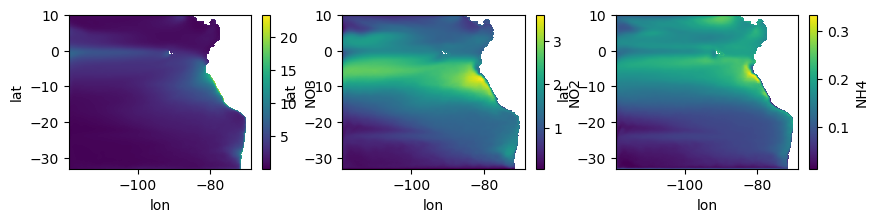

In [38]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(1,3,figsize=(10,2))
nitrogen_all_.NO3.mean('time').plot(ax=ax[0])
nitrogen_all_.NO2.mean('time').plot(ax=ax[1])
nitrogen_all_.NH4.mean('time').plot(ax=ax[2])


In [39]:
# nitrogen_all.to_netcdf('monthly/mask_250km/Nitrogen_10m.nc')